In [4]:
import mne
import matplotlib.pyplot as plt

In [6]:
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_file, preload=True)

Opening raw data file /Users/anushka.j/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


In [7]:
#finding the events (moments when stimuli were presented) in the raw data
events = mne.find_events(raw, stim_channel="STI 014")
print(events[:10])   # each row: [time, _, event_code]
print("Number of events found:", len(events))

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
[[27977     0     2]
 [28345     0     3]
 [28771     0     1]
 [29219     0     4]
 [29652     0     2]
 [30025     0     3]
 [30450     0     1]
 [30839     0     4]
 [31240     0     2]
 [31665     0     3]]
Number of events found: 320


In [8]:
# used these codes for different stimuli:
event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
}

# cut the EEG into windows: from 0.2s before each event to 0.5s after each event
epochs = mne.Epochs(
    raw, events, event_id=event_dict,
    tmin=-0.2, tmax=0.5,
    baseline=(-0.2, 0),   
    picks="eeg",          
    preload=True
)
print(epochs)

Not setting metadata
289 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 289 events and 421 original time points ...
0 bad epochs dropped
<Epochs | 289 events (all good), -0.2 – 0.499 s (baseline -0.2 – 0 s), ~58.6 MiB, data loaded,
 'auditory/left': 72
 'auditory/right': 73
 'visual/left': 73
 'visual/right': 71>


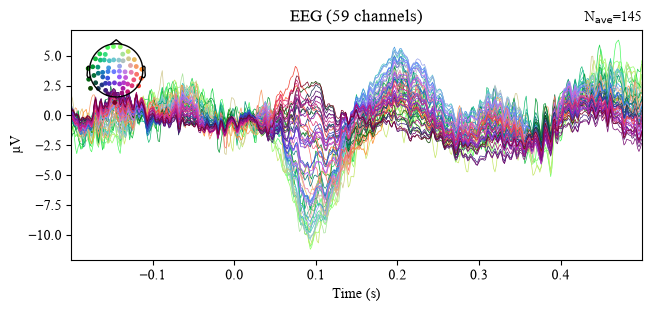

In [9]:
# avg all the auditory trials
evoked_auditory = epochs["auditory"].average()

# avg all the visual trials
evoked_visual = epochs["visual"].average()

# plot the auditory event related potential (ERP) response
evoked_auditory.plot()
plt.show()

combining channels using GFP (eeg channels)


combining channels using GFP (eeg channels)


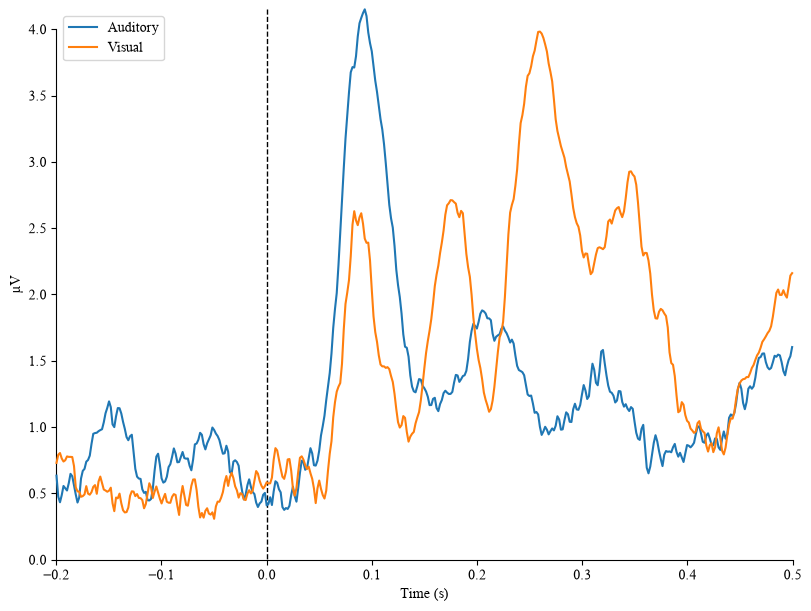

In [10]:
# plot auditory vs. visual responses to see them side by side
mne.viz.plot_compare_evokeds(
    {"Auditory": evoked_auditory, "Visual": evoked_visual}
)
plt.show()

In [11]:
import matplotlib.pyplot as plt
import matplotlib as mpl

In [12]:
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]

combining channels using GFP (eeg channels)


combining channels using GFP (eeg channels)


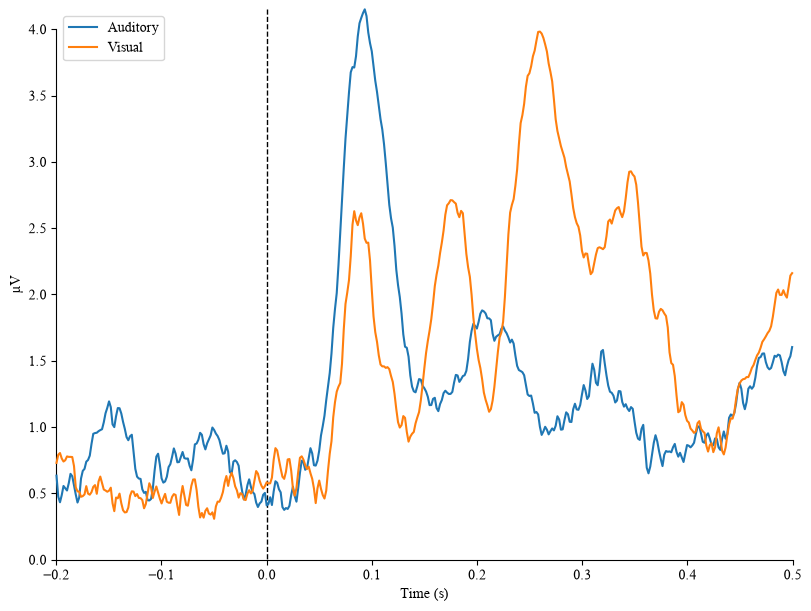

In [13]:
fig = mne.viz.plot_compare_evokeds(
    {"Auditory": evoked_auditory, "Visual": evoked_visual},
    show=False           
)[0]          

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl

In [15]:
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


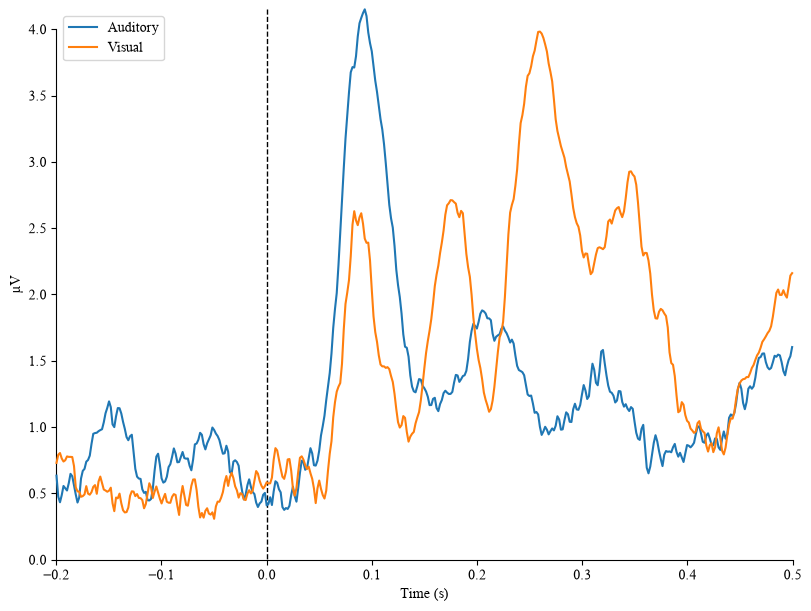

In [16]:
fig = mne.viz.plot_compare_evokeds(
    {"Auditory": evoked_auditory, "Visual": evoked_visual},
    show=False
)[0]     

In [17]:
fig.savefig("erp_comparison.png", dpi=300, bbox_inches="tight")


In [18]:
plt.show()  